# Repricing Benchmark Public API Demo

This notebook demonstrates the release-facing repricing benchmark API using local frozen artifacts.


In [1]:
import pandas as pd

from polymarket_research.benchmarks import evaluate_repricing, load_repricing
from polymarket_research.benchmarks.baselines import fit_repricing_train_rate_baseline
from polymarket_research.benchmarks.audit.reporting import benchmark_manifest_summary
from polymarket_research.benchmarks.visualization.plotting import (
    plot_binary_calibration,
    plot_label_distribution,
    plot_market_history,
    plot_precision_recall,
)

from polymarket_research.utils.filesystem import setup_root

pd.set_option("display.max_columns", 100)

REPO_ROOT = setup_root()
ARTIFACT_ROOT = REPO_ROOT / "benchmark_releases"
VERSION = "v1"


In [2]:
polymarket_bundle_dir = ARTIFACT_ROOT / "polymarket" / "repricing" / VERSION
polymarket_repricing = load_repricing(polymarket_bundle_dir)

kalshi_bundle_dir = ARTIFACT_ROOT / "kalshi" / "repricing" / VERSION
kalshi_repricing = load_repricing(kalshi_bundle_dir)

repricing_benchmarks = {
    "polymarket": polymarket_repricing,
    "kalshi": kalshi_repricing,
}

benchmark_manifest_summary(repricing_benchmarks)


,source,release_name,task,rows,markets,market_timeseries_rows,train_rows,test_rows,split_unit,split_unit_overlap,future_horizon_hours,positive_rate
0,polymarket,polymarket-repricing-24h,large_future_repricing_prediction,1316457,13995,206101450,1221863,94594,market_id,0,24,0.019335
1,kalshi,kalshi-repricing-24h,large_future_repricing_prediction,1383645,8026,203314679,1321457,62188,market_id,0,24,0.017037


## Polymarket


In [3]:
benchmark = repricing_benchmarks["polymarket"]

baseline = fit_repricing_train_rate_baseline(benchmark, split="train")
predictions = baseline.predict(benchmark, split="test")
report = evaluate_repricing(benchmark, predictions, split="test")

pd.Series(baseline.manifest(), dtype="object")


name                               repricing_train_rate_baseline
train_split                                                train
parameters     {'pred_prob': 0.016825945298286304, 'train_row...
dtype: object

In [4]:
display(report["overall"])
display(report["by_horizon"])
display(predictions.head())


,split,rows,log_loss,brier_score,roc_auc
0,test,94594,0.227471,0.050289,0.5


,split,future_horizon_hours,rows,log_loss,brier_score,roc_auc
0,test,24,94594,0.227471,0.050289,0.5


,market_id,timestamp_utc,pred_prob
0,995254,2025-12-24 20:10:00+00:00,0.016826
1,995256,2025-12-24 20:10:00+00:00,0.016826
2,995257,2025-12-24 20:10:00+00:00,0.016826
3,1002191,2025-12-24 20:25:00+00:00,0.016826
4,1004827,2025-12-24 20:50:00+00:00,0.016826


## Kalshi


In [5]:
benchmark = repricing_benchmarks["kalshi"]

baseline = fit_repricing_train_rate_baseline(benchmark, split="train")
predictions = baseline.predict(benchmark, split="test")
report = evaluate_repricing(benchmark, predictions, split="test")

pd.Series(baseline.manifest(), dtype="object")


name                               repricing_train_rate_baseline
train_split                                                train
parameters     {'pred_prob': 0.014543038479496496, 'train_row...
dtype: object

In [6]:
display(report["overall"])
display(report["by_horizon"])
display(predictions.head())


,split,rows,log_loss,brier_score,roc_auc
0,test,62188,0.309894,0.068204,0.5


,split,future_horizon_hours,rows,log_loss,brier_score,roc_auc
0,test,24,62188,0.309894,0.068204,0.5


,market_id,timestamp_utc,pred_prob
0,kalshi:KXRT-MEL-75,2026-01-10 15:10:00+00:00,0.014543
1,kalshi:KXRT-MEL-90,2026-01-10 15:10:00+00:00,0.014543
2,kalshi:KXSHUTDOWNBY-26DEC31,2026-01-10 15:25:00+00:00,0.014543
3,kalshi:KXALBUMSALES-DBD-120000,2026-01-10 16:05:00+00:00,0.014543
4,kalshi:KXRT-MEL-45,2026-01-10 16:50:00+00:00,0.014543


## Side-by-side Baseline Summary


In [7]:
summary_rows = []

for source, benchmark in repricing_benchmarks.items():
    baseline = fit_repricing_train_rate_baseline(benchmark, split="train")
    predictions = baseline.predict(benchmark, split="test")
    report = evaluate_repricing(benchmark, predictions, split="test")
    row = report["overall"].iloc[0].to_dict()
    row["source"] = source
    row["baseline"] = baseline.manifest()["name"]
    summary_rows.append(row)

pd.DataFrame(summary_rows).loc[:, ["source", "baseline", "split", "rows", "log_loss", "brier_score", "roc_auc"]]


,source,baseline,split,rows,log_loss,brier_score,roc_auc
0,polymarket,repricing_train_rate_baseline,test,94594,0.227471,0.050289,0.5
1,kalshi,repricing_train_rate_baseline,test,62188,0.309894,0.068204,0.5


## Visual Checks

These plots use only frozen artifacts, baseline predictions, and evaluator reports.


<Axes: title={'center': 'Polymarket repricing test labels'}, xlabel='label', ylabel='rows'>

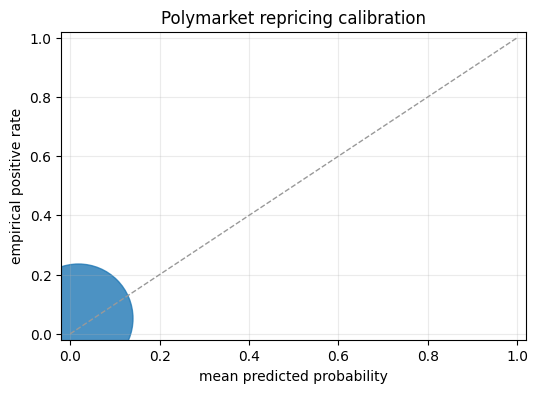

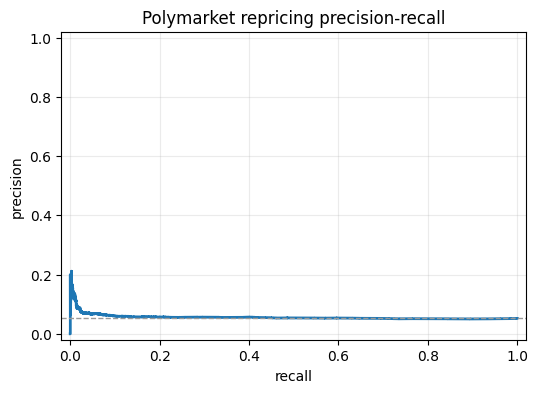

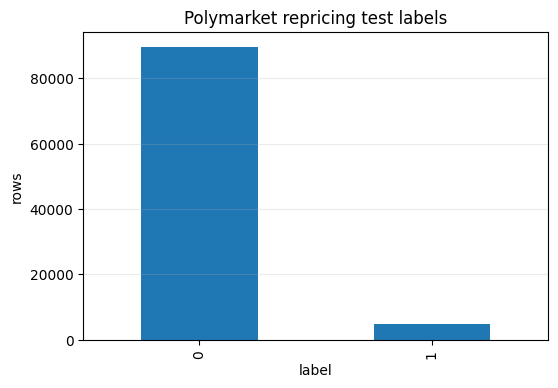

In [8]:
benchmark = repricing_benchmarks["polymarket"]
baseline = fit_repricing_train_rate_baseline(benchmark, split="train")
predictions = baseline.predict(benchmark, split="test")

plot_binary_calibration(benchmark, predictions, split="test", title="Polymarket repricing calibration")
plot_precision_recall(benchmark, predictions, split="test", title="Polymarket repricing precision-recall")
plot_label_distribution(benchmark, split="test", title="Polymarket repricing test labels")


## Optional Inspection


market_id                                  517036
timestamp_utc           2025-01-02 15:40:00+00:00
future_horizon_hours                           24
label                                           0
Name: 0, dtype: object

,market_id,timestamp_utc,yes_probability
284,517036,2025-01-02 15:20:00+00:00,0.78
285,517036,2025-01-02 15:25:00+00:00,0.78
286,517036,2025-01-02 15:30:00+00:00,0.78
287,517036,2025-01-02 15:35:00+00:00,0.78
288,517036,2025-01-02 15:40:00+00:00,0.81


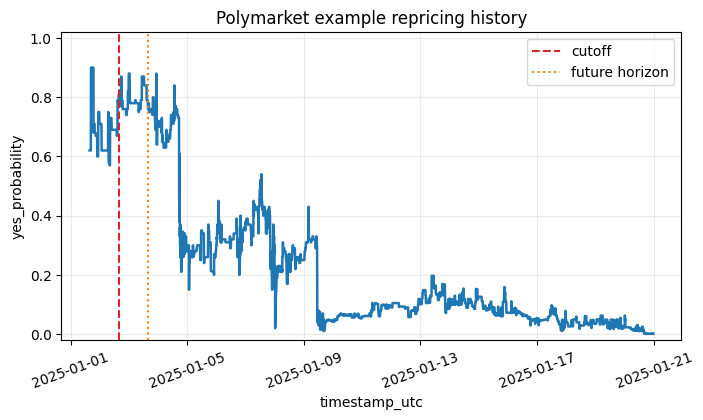

In [9]:
benchmark = repricing_benchmarks["polymarket"]
example = benchmark.input_frame().iloc[0]
market_id = str(example["market_id"])
timestamp_utc = pd.Timestamp(example["timestamp_utc"])
future_until = timestamp_utc + pd.Timedelta(hours=int(example["future_horizon_hours"]))
target_row = benchmark.targets().loc[
    lambda df: (df["market_id"].astype(str) == market_id)
    & (pd.to_datetime(df["timestamp_utc"], utc=True, errors="coerce").eq(timestamp_utc))
    & (df["future_horizon_hours"].eq(example["future_horizon_hours"]))
].iloc[0]

plot_market_history(
    benchmark,
    market_id=market_id,
    cutoff=timestamp_utc,
    future_until=future_until,
    title="Polymarket example repricing history",
)
example_display = pd.concat([
    benchmark.resolve_market_snapshot(market_id, timestamp_utc),
    target_row.drop(labels=["market_id", "timestamp_utc", "future_horizon_hours", "split"], errors="ignore"),
])
display(example_display.loc[["market_id", "timestamp_utc", "future_horizon_hours", "label", "future_move"]])
benchmark.history_until(market_id, timestamp_utc).tail()
